In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as sts
from tqdm import tqdm
from sklearn import metrics
from datetime import timedelta, datetime
import statsmodels

import warnings
warnings.filterwarnings("ignore")

In [253]:
def plot_acf_pacf(timeseries):
    """
    Функция, отображающая график временного ряда,
    автокорреляционную функцию(ACF)
    и частную автокорреляционную функцию(PACF).
    """
    fig = plt.figure(figsize=(16,20))

    ax0 = fig.add_subplot(311)
    timeseries.plot(ax=ax0)
    ax0.set_title('График временного ряда')
    ax0.set_xlabel('Дата')
    ax0.set_ylabel('Количество новых заболеваний')

    ax1 = fig.add_subplot(312)
    fig = sm.graphics.tsa.plot_acf(timeseries, ax=ax1)
    ax1.set_title('Автокорреляционная функция')

    ax2 = fig.add_subplot(313)
    fig = sm.graphics.tsa.plot_pacf(timeseries, ax=ax2)
    ax2.set_title('Частная автокорреляционная функция')

def adf_test(timeseries):
    pvalue = sm.tsa.stattools.adfuller(timeseries)[1]
    print("Критерий Дики-Фуллера: p=%f" % pvalue)
    if pvalue > 0.05:
        print("Ряд нестационарен, нужно большее d")
    else:
        print("Ряд стационарен, d подходит")
    pvalue = sm.tsa.stattools.adfuller(timeseries, regression='c')[1]
    print("Критерий Дики-Фуллера с константой: p=%f" % pvalue)
    if pvalue > 0.05:
        print("Ряд нестационарен")
    else:
        print("Ряд стационарен")
    pvalue = sm.tsa.stattools.adfuller(timeseries, regression='ct')[1]
    print("Критерий Дики-Фуллера с константой и трендом: p=%f" % pvalue)
    if pvalue > 0.05:
        print("Ряд нестационарен")
    else:
        print("Ряд стационарен")
    pvalue = sm.tsa.stattools.adfuller(timeseries, regression='ctt')[1]
    print("Критерий Дики-Фуллера с константой, линейным и квадратичным трендом: p=%f" % pvalue)
    if pvalue > 0.05:
        print("Ряд нестационарен")
    else:
        print("Ряд стационарен")
    pvalue = sm.tsa.stattools.adfuller(timeseries, regression='n')[1]
    print("Критерий Дики-Фуллера без константы и тренда: p=%f" % pvalue)
    if pvalue > 0.05:
        print("Ряд нестационарен")
    else:
        print("Ряд стационарен")


In [254]:
# функция с построением моделей
def adf_test3(timeseries):
    dif_1 = ts.diff().dropna()
    print('\nШАГ 1')
    print('\nОцениваем модель авторегрессии 1го порядка с трендом и константой')
    print(statsmodels.tsa.ar_model.AutoReg(timeseries,lags=1,trend='ct').fit().summary())
    # проверка гипотезы о равенстве коэфффициента авторегрессии 0
    pvalue = sm.tsa.stattools.adfuller(timeseries, regression='ct')[1]
    print("\nКритерий Дики-Фуллера с константой и линейным трендом (о равенсте коэф авторегрессии 0): p=%f" % pvalue)
    if pvalue > 0.05:
        # нулевая гипотеза принимается
        print('\nСтроим модель только с трендом и конст, чтобы убедиться, что правильно включили тренд')
        print(statsmodels.tsa.ar_model.AutoReg(dif_1,lags=0,trend='ct').fit().summary())
        print("\nЕсли коэффициент при тренде значим, ряд класса DS (случайное блуждание с дрейфом и детерминированным трендом)")
    else:
        print("\nРяд класса TS")

    print('\nШАГ 2')
    print('\nОцениваем модель авторегрессии 1го порядка с константой')
    print(statsmodels.tsa.ar_model.AutoReg(timeseries,lags=1,trend='c').fit().summary())
    # проверка гипотезы о равенсте коэф авторегрессии 0
    pvalue = sm.tsa.stattools.adfuller(timeseries, regression='c')[1]
    print("\nКритерий Дики-Фуллера с константой (о равенсте коэф авторегрессии 0): p=%f" % pvalue)
    if pvalue > 0.05:
        # нулевая гипотеза принимается
        print('\nСтроим модель только с конст, чтобы убедиться, что правильно включили конст')
        print(statsmodels.tsa.ar_model.AutoReg(dif_1,lags=0,trend='c').fit().summary())
        print("\nЕсли коэффициент при константе значим, ряд класса DS (случайное блуждание с дрейфом)")
    else:
        print("\nРяд класса TS (стационарный ряд с ненулевой средней)")

    print('\nШАГ 3')
    print('\nОцениваем модель авторегрессии 1го порядка без константы')
    print(statsmodels.tsa.ar_model.AutoReg(timeseries,lags=1,trend='n').fit().summary())
    # проверка гипотезы о равенсте коэф авторегрессии 0
    pvalue = sm.tsa.stattools.adfuller(timeseries, regression='n')[1]
    print("\nКритерий Дики-Фуллера без константы и тренда (о равенсте коэф авторегрессии 0): p=%f" % pvalue)
    if pvalue > 0.05:
        # нулевая гипотеза принимается
        print("\nРяд класса DS (случайное блуждание без дрейфа)")
    else:
        print("\nРяд класса TS (процесс AR с нулевым мат ожиданием)")

In [255]:
# критерий Квятковского-Филипса-Шмидта-Шина (KPSS тест)
def KPSS_test(timeseries):
  print('КPSS тест')
  # проверка на тренд-стационарность ряда
  results = []
  for n_lag in range(1, 11):
    results.append(sm.tsa.stattools.kpss(timeseries, regression='ct', nlags = n_lag))
  print(f'Критические значения статистики:\n\n{' '.join([f'{key}: {results[0][3][key]}' for key in results[0][3]])}')
  print(f'\n{'Порядок лага':<15s}\t{'Значение статистики':<23s}\t{'P-value':<15s}')
  for result in results:
    print(f'{str(result[2]):<15s}\t{str(result[0]):<23s}\t{str(result[1]):<15s}')
  p_value = sm.tsa.stattools.kpss(timeseries, regression='ct')[1]
  print("\nКритерий Квятковского-Филипса-Шмидта-Шина (о тренд-стационарности ряда): p=%f" % p_value)
  if p_value > 0.05:
    # нулевая гипотеза принимается
    print('\nРяд класса TS')
  else:
    print('\nРяд класса DS')

In [256]:
# функция для парсинга дат
def parse_date(date: str) -> datetime:
    months = {
        "января": 1, "февраля": 2, "марта": 3, "апреля": 4,
        "мая": 5, "июня": 6, "июля": 7, "августа": 8,
        "сентября": 9, "октября": 10, "ноября": 11, "декабря": 12,
    }
    date = date.replace(" г.", "").strip()
    day_str, month_str, year_str = date.split()
    return datetime(int(year_str), months[month_str], int(day_str))

# Загрузка данных

In [257]:
ts = pd.read_excel('Лаба№5_МСМП.xlsx', index_col='Date', parse_dates=True).dropna() # !
if ts.index.dtype == 'object':
  ts.index = ts.index.to_series().apply(parse_date)
print(f"Длина временного ряда: {ts.shape[0]}")
ts.head(15)

Длина временного ряда: 246


,New cases
Date,
2020-03-31,25
2020-04-07,48
2020-04-14,157
2020-04-21,402
2020-04-28,485
2020-05-05,644
2020-05-12,551
2020-05-19,537
2020-05-26,395


Text(0, 0.5, 'Количество новых заболеваний')

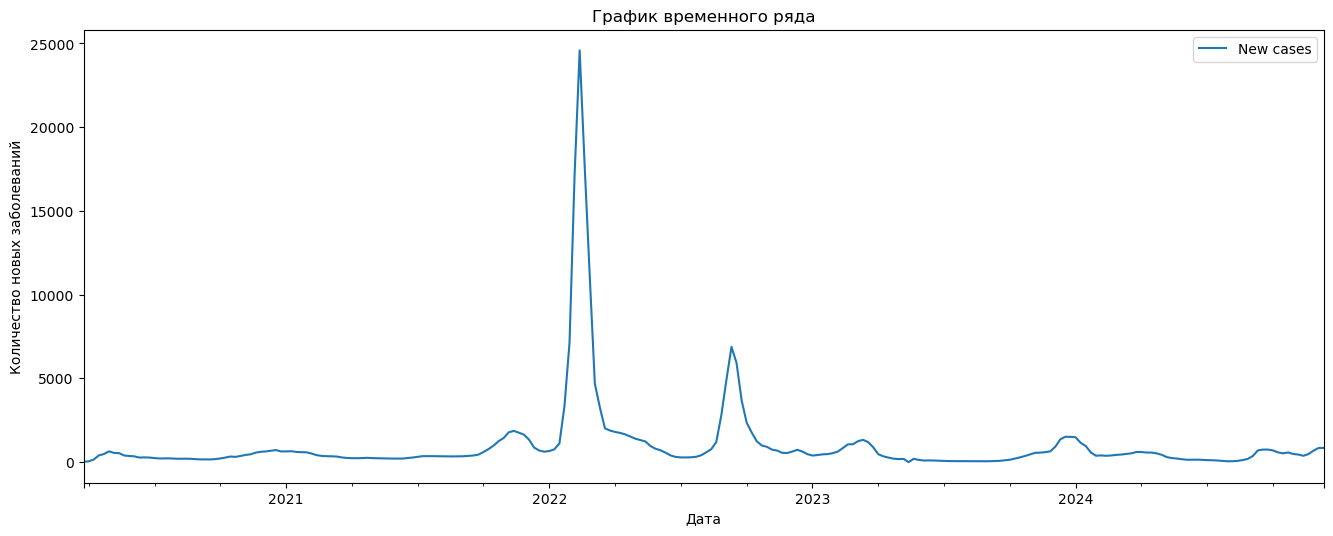

In [258]:
fig = plt.figure(figsize=(16,20))

ax0 = fig.add_subplot(311)
ts.plot(ax=ax0)
ax0.set_title('График временного ряда')
ax0.set_xlabel('Дата')
ax0.set_ylabel('Количество новых заболеваний')

# Определение типа ряда (TS/DS)

In [259]:
adf_test3(ts)
print('\n' + '-'*100)
KPSS_test(ts)


ШАГ 1

Оцениваем модель авторегрессии 1го порядка с трендом и константой
                            AutoReg Model Results                             
Dep. Variable:              New cases   No. Observations:                  246
Model:                     AutoReg(1)   Log Likelihood               -2070.269
Method:               Conditional MLE   S.D. of innovations           1131.320
Date:                Mon, 15 Dec 2025   AIC                           4148.539
Time:                        21:19:12   BIC                           4162.544
Sample:                    04-07-2020   HQIC                          4154.179
                         - 12-10-2024                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          150.7720    149.886      1.006      0.314    -143.000     444.544
trend           -0.2767      1.023     -0.271      

# Определение порядка разности d и компонент p, q.

### График временного ряда, АКФ и ЧАКФ

Критерий Дики-Фуллера: p=0.000006
Ряд стационарен, d подходит
Критерий Дики-Фуллера с константой: p=0.000006
Ряд стационарен
Критерий Дики-Фуллера с константой и трендом: p=0.000059
Ряд стационарен
Критерий Дики-Фуллера с константой, линейным и квадратичным трендом: p=0.000129
Ряд стационарен
Критерий Дики-Фуллера без константы и тренда: p=0.000003
Ряд стационарен
------------------------------
КPSS тест
Критические значения статистики:

10%: 0.119 5%: 0.146 2.5%: 0.176 1%: 0.216

Порядок лага   	Значение статистики    	P-value        
1              	0.40050914153567446    	0.01           
2              	0.2896572196808814     	0.01           
3              	0.23849801089473308    	0.01           
4              	0.210200395137766      	0.012174851823337747
5              	0.1926150063369785     	0.018769372623633058
6              	0.18072201141725067    	0.023229245718530998
7              	0.17211002096383263    	0.028241649196806138
8              	0.16551873200089687    	0.0337

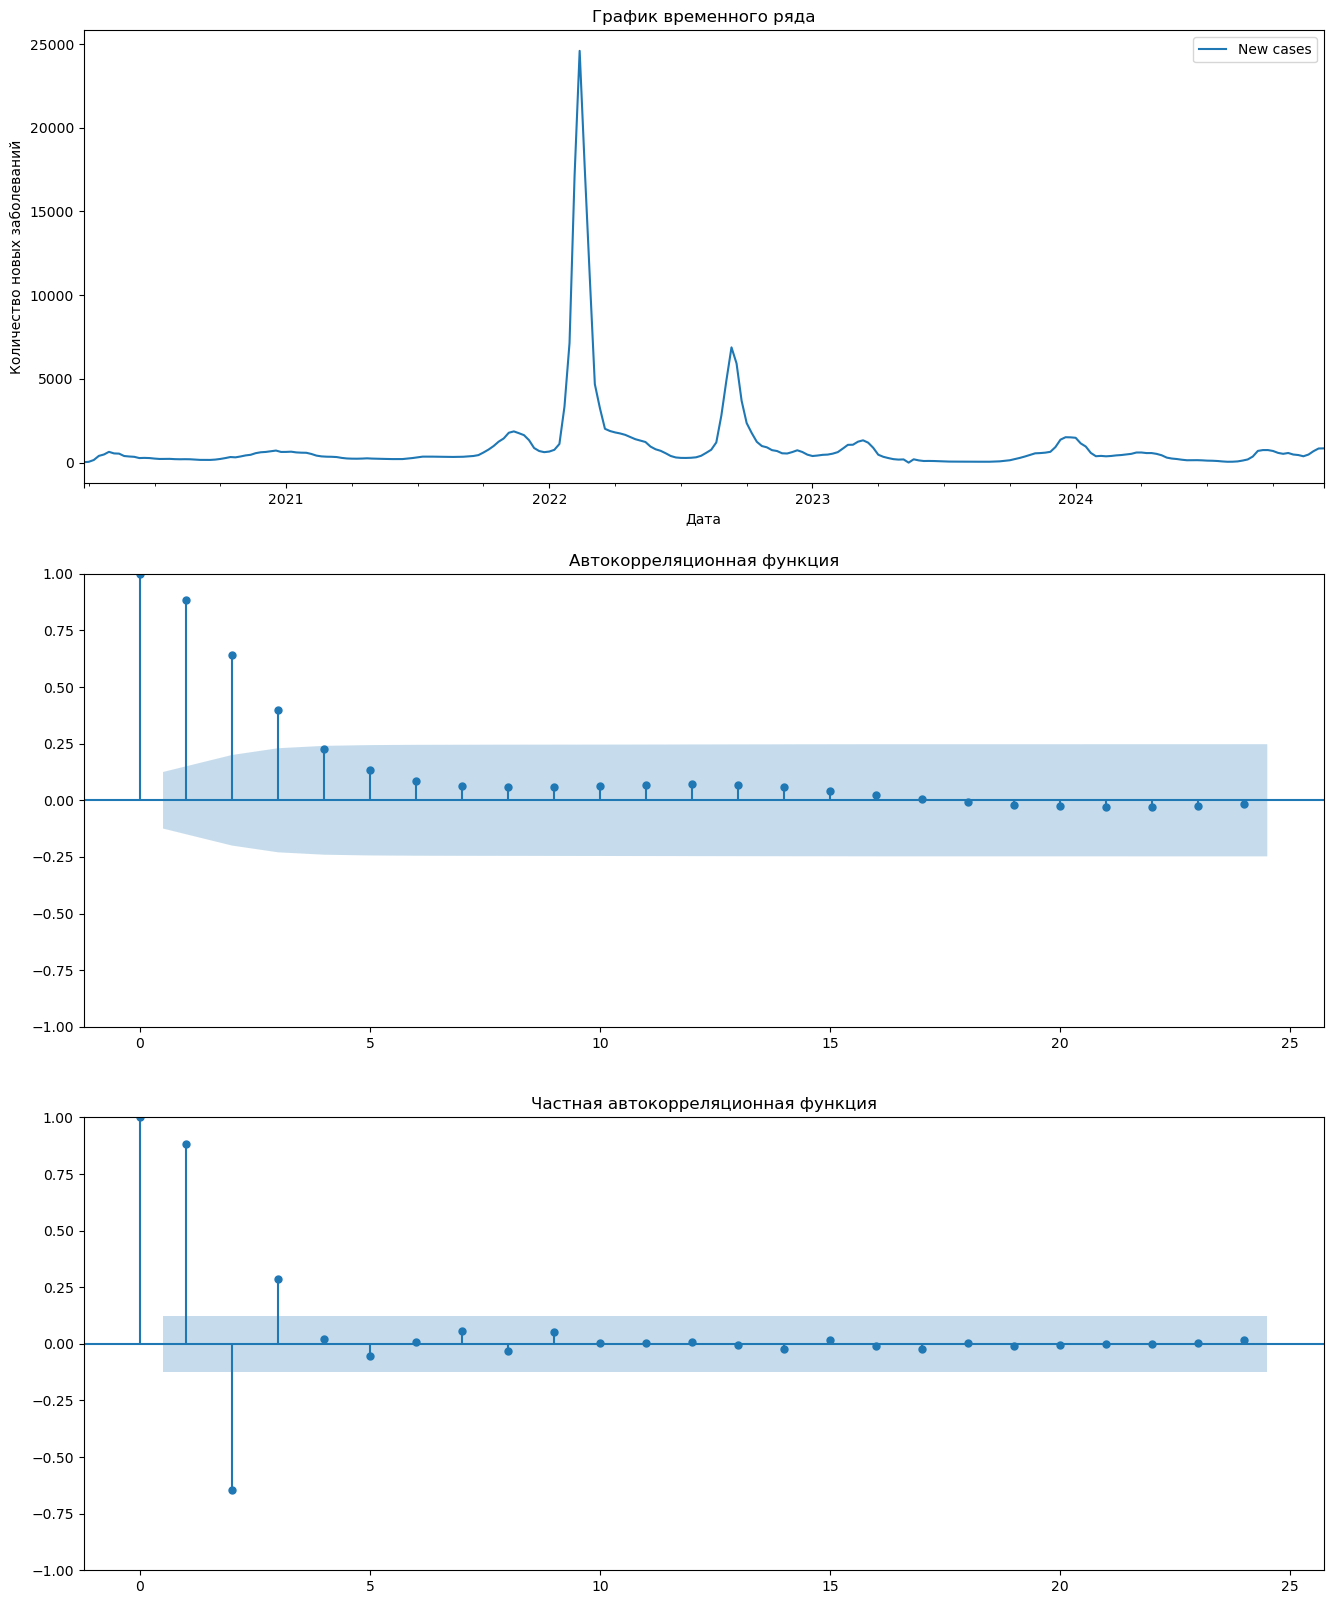

In [260]:
adf_test(ts)
print('-'*30)
KPSS_test(ts)
plot_acf_pacf(ts)

### График первых разностей

Критерий Дики-Фуллера: p=0.000000
Ряд стационарен, d подходит
Критерий Дики-Фуллера с константой: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой и трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой, линейным и квадратичным трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера без константы и тренда: p=0.000000
Ряд стационарен
------------------------------
КPSS тест
Критические значения статистики:

10%: 0.119 5%: 0.146 2.5%: 0.176 1%: 0.216

Порядок лага   	Значение статистики    	P-value        
1              	0.011146537970522664   	0.1            
2              	0.009983852351845178   	0.1            
3              	0.010384822360545007   	0.1            
4              	0.011557293275905323   	0.1            
5              	0.013135680895157625   	0.1            
6              	0.014987721069264217   	0.1            
7              	0.016988150949650397   	0.1            
8              	0.019129570795130918   	0.1            
9         

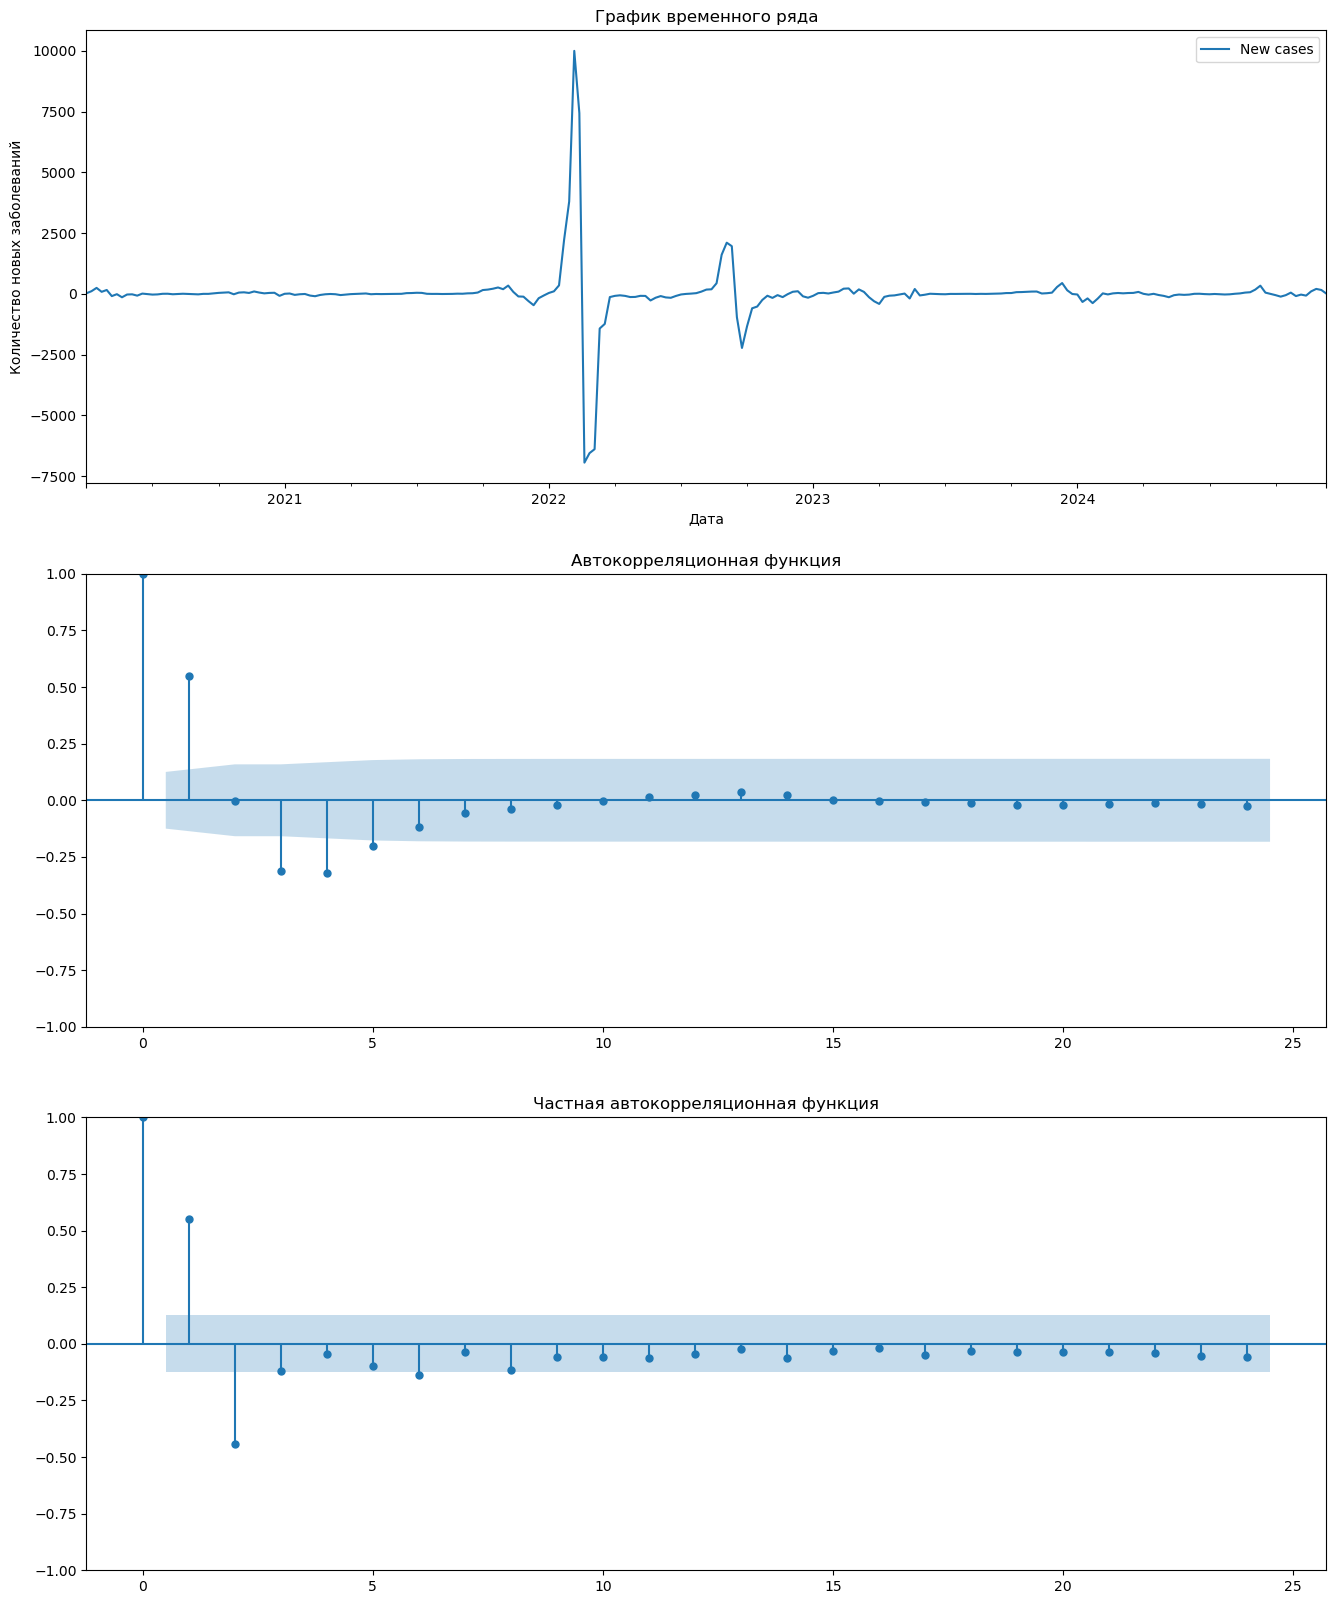

In [261]:
dif_1 = ts.diff().dropna()
adf_test(dif_1)
print('-'*30)
KPSS_test(dif_1)
plot_acf_pacf(dif_1)

### График вторых разностей

Критерий Дики-Фуллера: p=0.000000
Ряд стационарен, d подходит
Критерий Дики-Фуллера с константой: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой и трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой, линейным и квадратичным трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера без константы и тренда: p=0.000000
Ряд стационарен
------------------------------
КPSS тест
Критические значения статистики:

10%: 0.119 5%: 0.146 2.5%: 0.176 1%: 0.216

Порядок лага   	Значение статистики    	P-value        
1              	0.0040805252497146055  	0.1            
2              	0.00467762413144691    	0.1            
3              	0.006201090861449145   	0.1            
4              	0.008528308824009056   	0.1            
5              	0.010979346983345569   	0.1            
6              	0.013591031713472958   	0.1            
7              	0.015804614396719964   	0.1            
8              	0.018060875537420223   	0.1            
9         

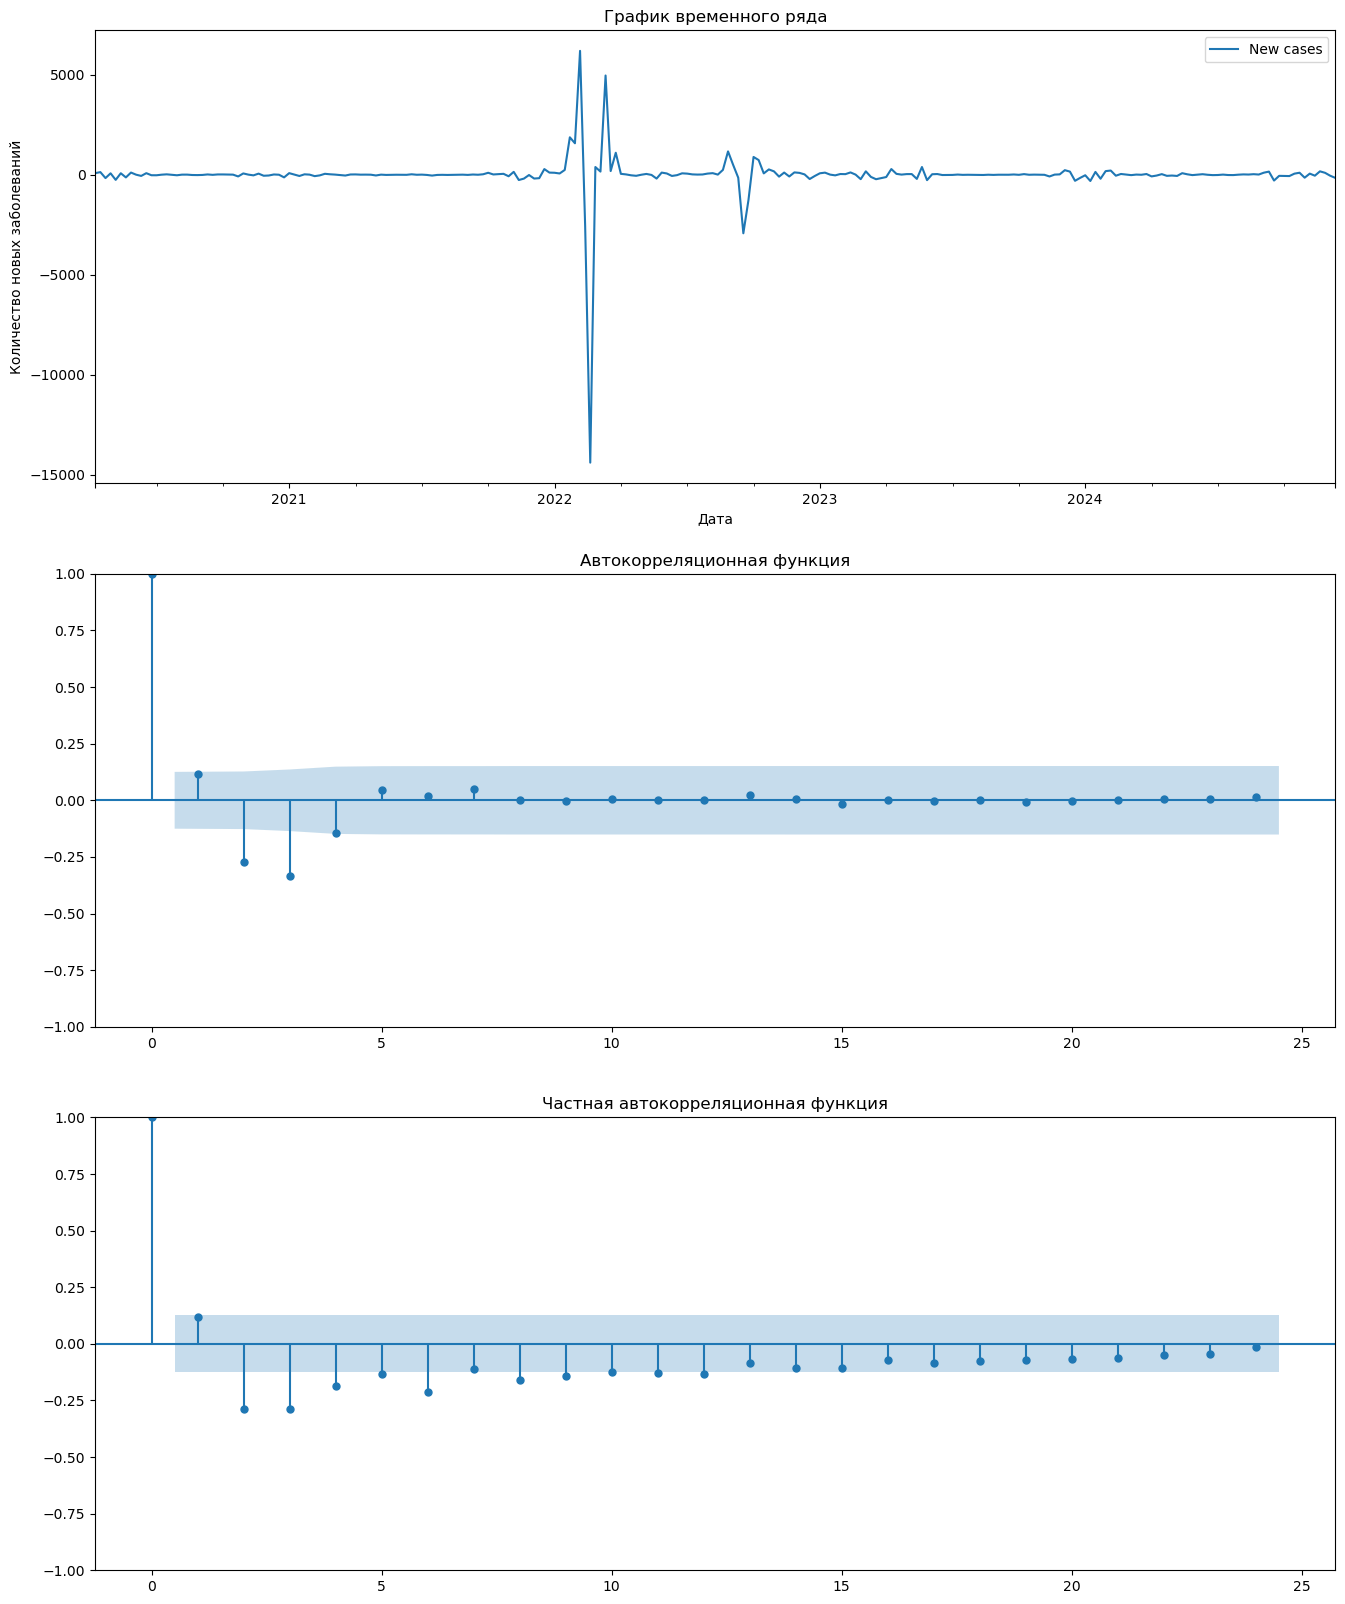

In [262]:
dif_2 = ts.diff().diff().dropna()
adf_test(dif_2)
print('-'*30)
KPSS_test(dif_2)
plot_acf_pacf(dif_2)

### p и q определяются по графикам АКФ и ЧАКФ для подходящего значения d

# Оценка параметров моделей

* Log Lokehood - логарифм правдоподобия
* S.D. of inovations - стандартная ошибка модели
* AIC - информационный критерий Аккаике
* BIC - информационный критерий Байеса
* HQIC - информационный критерий Хеннана-Куинна
* coef - значение коэффициента
* P>|z| - p-value для гипотезы о незначимости коэффициента (если больше 0.05 - незначим)

## Model 1: (1,1,0)

In [263]:
model1 = sm.tsa.ARIMA(ts, order=(1,1,0)).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              New cases   No. Observations:                  246
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -2033.552
Date:                Mon, 15 Dec 2025   AIC                           4071.104
Time:                        21:19:14   BIC                           4078.106
Sample:                    03-31-2020   HQIC                          4073.924
                         - 12-10-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5493      0.013     43.739      0.000       0.525       0.574
sigma2      9.516e+05   1.65e+04     57.621      0.000    9.19e+05    9.84e+05
===================================================================================
Ljung-Box (L1) (Q):                  14.63   Jarque-Bera (JB):             71542.80
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               3.07   Skew:                            -3.80
Prob(H) (two-sided):                  0.00   Kurtosis:                        86.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Model 2: (0,1,1)

In [264]:
model2 = sm.tsa.ARIMA(ts, order=(0,1,1)).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              New cases   No. Observations:                  246
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -2023.471
Date:                Mon, 15 Dec 2025   AIC                           4050.941
Time:                        21:19:14   BIC                           4057.944
Sample:                    03-31-2020   HQIC                          4053.761
                         - 12-10-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6236      0.022     28.107      0.000       0.580       0.667
sigma2      8.726e+05    1.6e+04     54.530      0.000    8.41e+05    9.04e+05
===================================================================================
Ljung-Box (L1) (Q):                   4.58   Jarque-Bera (JB):             31499.37
Prob(Q):                              0.03   Prob(JB):                         0.00
Heteroskedasticity (H):               2.62   Skew:                            -0.61
Prob(H) (two-sided):                  0.00   Kurtosis:                        58.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Model 3: (1,1,1)

In [265]:
model3 = sm.tsa.ARIMA(ts, order=(1,1,1)).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              New cases   No. Observations:                  246
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2018.278
Date:                Mon, 15 Dec 2025   AIC                           4042.556
Time:                        21:19:14   BIC                           4053.060
Sample:                    03-31-2020   HQIC                          4046.786
                         - 12-10-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3035      0.021     14.423      0.000       0.262       0.345
ma.L1          0.4513      0.031     14.770      0.000       0.391       0.511
sigma2      9.001e+05   1.81e+04     49.651      0.000    8.65e+05    9.36e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.32   Jarque-Bera (JB):             52921.38
Prob(Q):                              0.57   Prob(JB):                         0.00
Heteroskedasticity (H):               2.78   Skew:                            -2.47
Prob(H) (two-sided):                  0.00   Kurtosis:                        74.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Model 4: перебор параметров

In [266]:
d = range(0, 2)
q = range(0, 7)
p = range(0, 7)

from itertools import product

parameters = list(product(p,d,q))
len(parameters)

98

In [267]:
# Может выполняться несколько минут
results = []
best_bic = float("inf")

for param in tqdm(parameters):
    #try except нужен, потому что на некоторых наборах параметров модель не обучается
    try:
        model = sm.tsa.ARIMA(ts, order=param).fit()
    except ValueError:
        continue
    bic = model.bic
    #сохраняем лучшую модель, bic, параметры
    if bic < best_bic:
        best_model = model
        best_bic = bic
        best_param = param
    results.append([param, model.bic])

result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'bic']
result_table.sort_values(by = 'bic', ascending=True).head(5)

100%|██████████| 98/98 [00:19<00:00,  4.92it/s]


,parameters,bic
50,"(3, 1, 1)",4018.695267
25,"(1, 1, 4)",4022.481387
37,"(2, 1, 2)",4022.821109
38,"(2, 1, 3)",4024.150778
24,"(1, 1, 3)",4024.461612


### Выбираем модель

In [268]:
def get_answer():
  # обработка ответа выбора модели
  answer = input('Вы хотите использовать лучшие параметры для модели (p, d, q) или сами хотите их ввести? (0 - лучшие, 1 - ввод): ').strip()
  while True:
    try:
      answer = int(answer)
      if answer > 1 or answer < 0:
        print('\nВы ввели неправильное число!')
      else:
        return answer
    except:
      print('\nВы ввели не число!')
    answer = input('\nВведите снова: (0 - лучшие параметры, 1 - ввод параметров): ')

def input_params():
  # обработка входного текста для извлечения параметров
  p_d_q = input('\nВведите через пробел 3 числа в следующем порядке (p, d, q): ').strip()
  while True:
    try:
      p, d, q = [int(value) for value in p_d_q.split(' ')]
      return p, d, q
    except:
      print('\nНеправильный ввод!')
    p_d_q = input('\nВведите снова через пробел 3 числа в следующем порядке (p, d, q): ')

def choose_model():
  # функция выбора модели
  answer = get_answer()
  if answer == 0:
    model = best_model
    p, d, q  = best_param
  else:
    p, d, q = input_params()
    model = sm.tsa.ARIMA(ts, order=(p, d, q)).fit()
  print(f'\nВыбрана модель со следующими параметрами ({p}, {d}, {q})')
  return model

In [269]:
model = choose_model()


Выбрана модель со следующими параметрами (3, 1, 1)


---

# Проверка адекватности модели


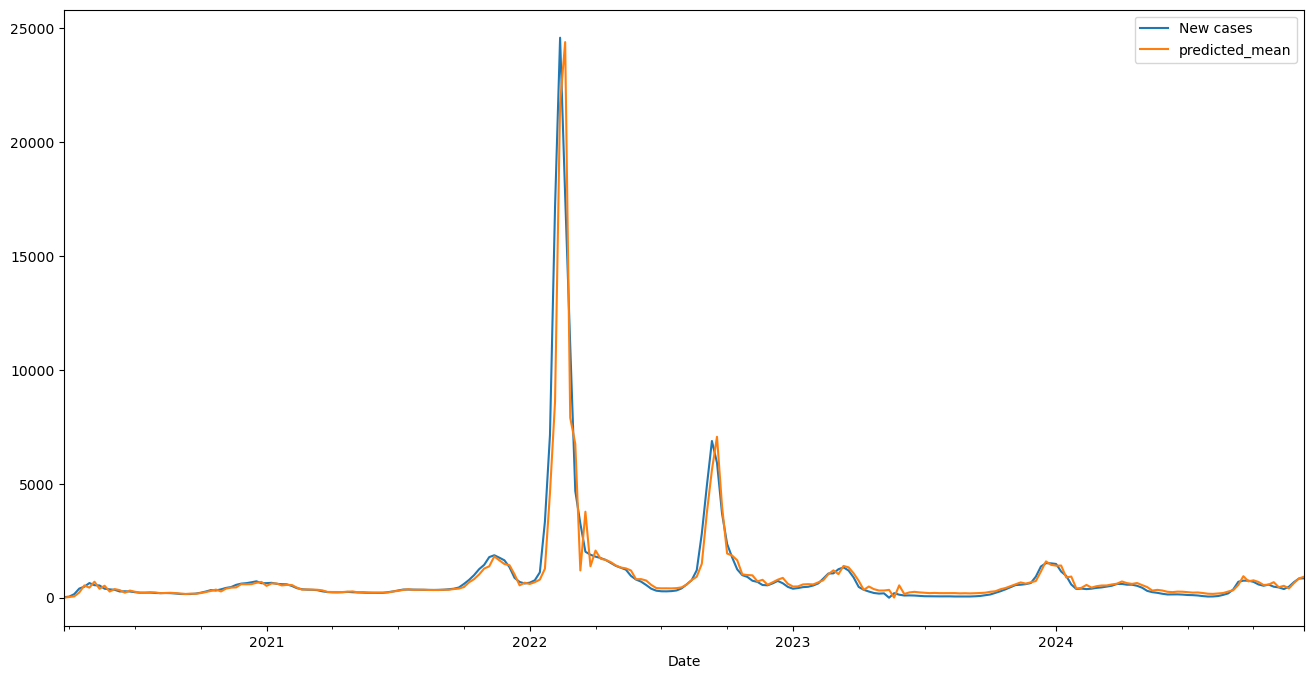

In [270]:
fig, ax = plt.subplots(figsize=(16,8))
ts.plot(ax=ax)
pred = model.predict()
pred.plot(ax=ax)
plt.legend()
fig.show()

In [296]:
pred = model.predict()
pred.to_frame()

,predicted_mean
2020-03-31,0.000000
2020-04-07,32.871728
2020-04-14,57.968317
2020-04-21,230.470640
2020-04-28,540.028869
...,...
2024-11-12,522.749050
2024-11-19,408.448974
2024-11-26,645.098835
2024-12-03,848.483819


In [297]:
print('MSE =', metrics.mean_squared_error(ts, pred))
print('RMSE =', np.sqrt(metrics.mean_squared_error(ts, pred)))
print('MAE =', metrics.mean_absolute_error(ts, pred))
print('MAPE =', metrics.mean_absolute_percentage_error(ts, pred))
print('R2 =', metrics.r2_score(ts, pred))

MSE = 688114.9772978514
RMSE = 829.5269599584159
MAE = 237.94579782011792
MAPE = 6301734438778782.0
R2 = 0.8823025702533998


# Проверка нормальности остатков

Критерий Дики-Фуллера: p=0.000000
Ряд стационарен, d подходит
Критерий Дики-Фуллера с константой: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой и трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой, линейным и квадратичным трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера без константы и тренда: p=0.000000
Ряд стационарен
------------------------------
КPSS тест
Критические значения статистики:

10%: 0.119 5%: 0.146 2.5%: 0.176 1%: 0.216

Порядок лага   	Значение статистики    	P-value        
1              	0.08451385911505528    	0.1            
2              	0.08364579235457352    	0.1            
3              	0.08530884136745538    	0.1            
4              	0.08667632145002539    	0.1            
5              	0.08613631521274431    	0.1            
6              	0.0874104567833004     	0.1            
7              	0.08811112781825649    	0.1            
8              	0.08931215277639958    	0.1            
9         

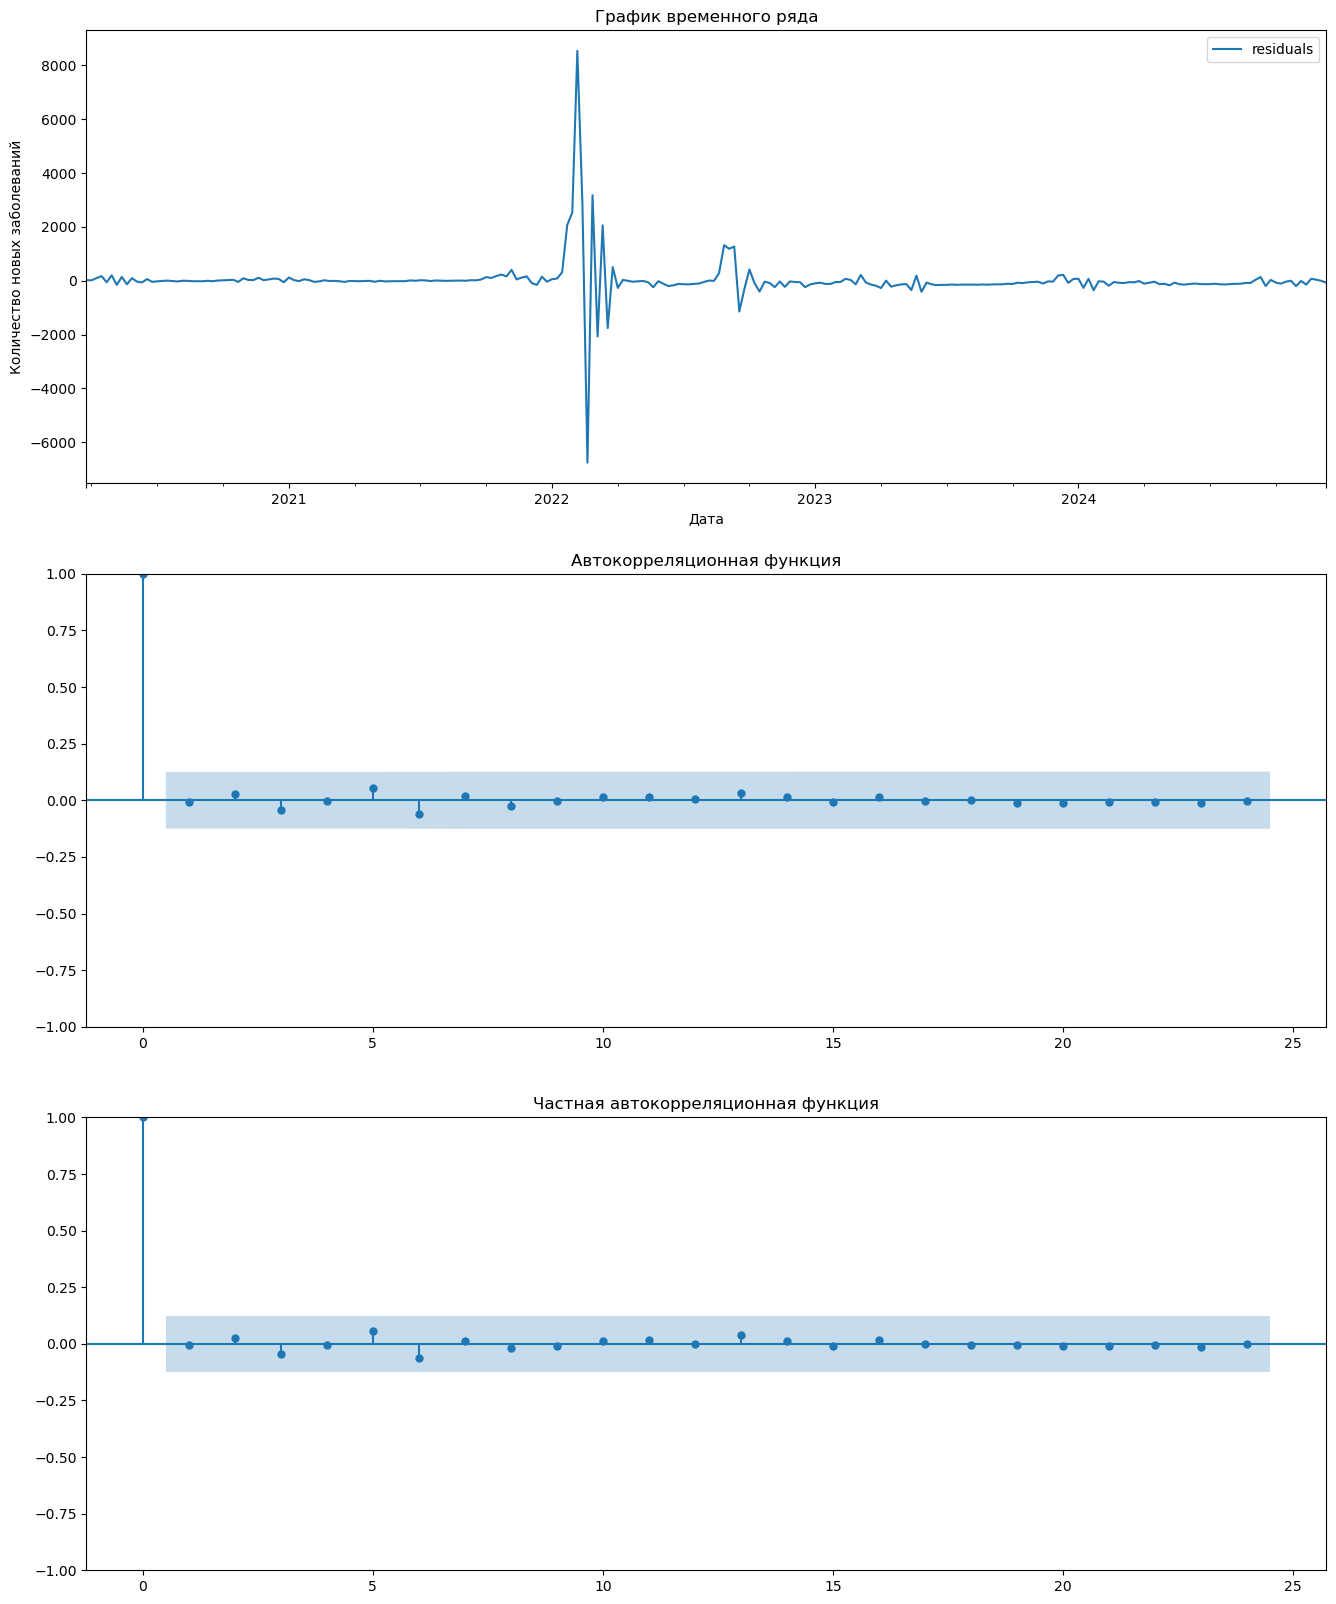

In [272]:
resid = pd.DataFrame(model.resid, columns=['residuals'])
adf_test(resid)
print('-'*30)
KPSS_test(resid)
plot_acf_pacf(resid)

Тест на нормальность: p = 0.000000
Распределение остатков ненормальное


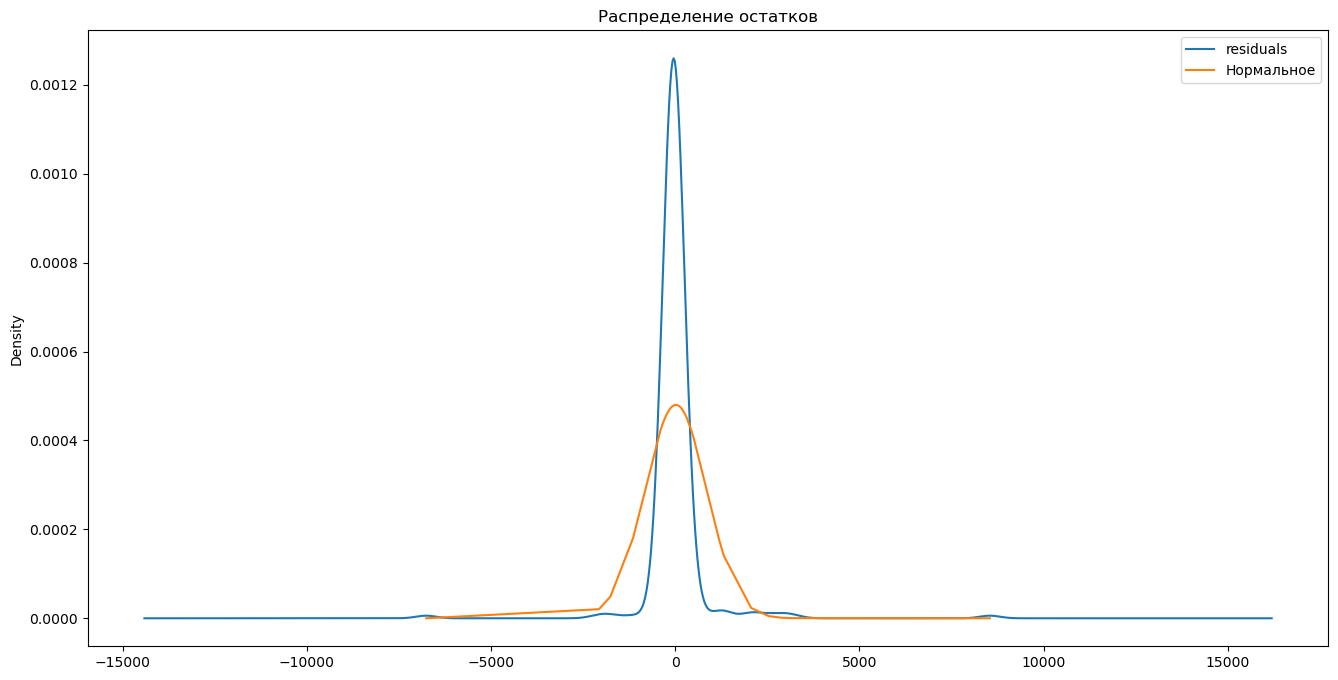

In [273]:
pvalue = sts.normaltest(resid['residuals'])[1]
print("Тест на нормальность: p = %f" % pvalue)
if pvalue > 0.05:
    print("Распределение остатков нормальное")
else:
    print("Распределение остатков ненормальное")

fig, ax = plt.subplots(figsize=(16,8))
resid.plot.kde(ax=ax)
plt.title('Распределение остатков')
plt.plot(resid.sort_values(by = 'residuals'), sts.norm.pdf(resid.sort_values(by = 'residuals'), resid.mean(), resid.std()), label='Нормальное')
plt.legend()
fig.show()

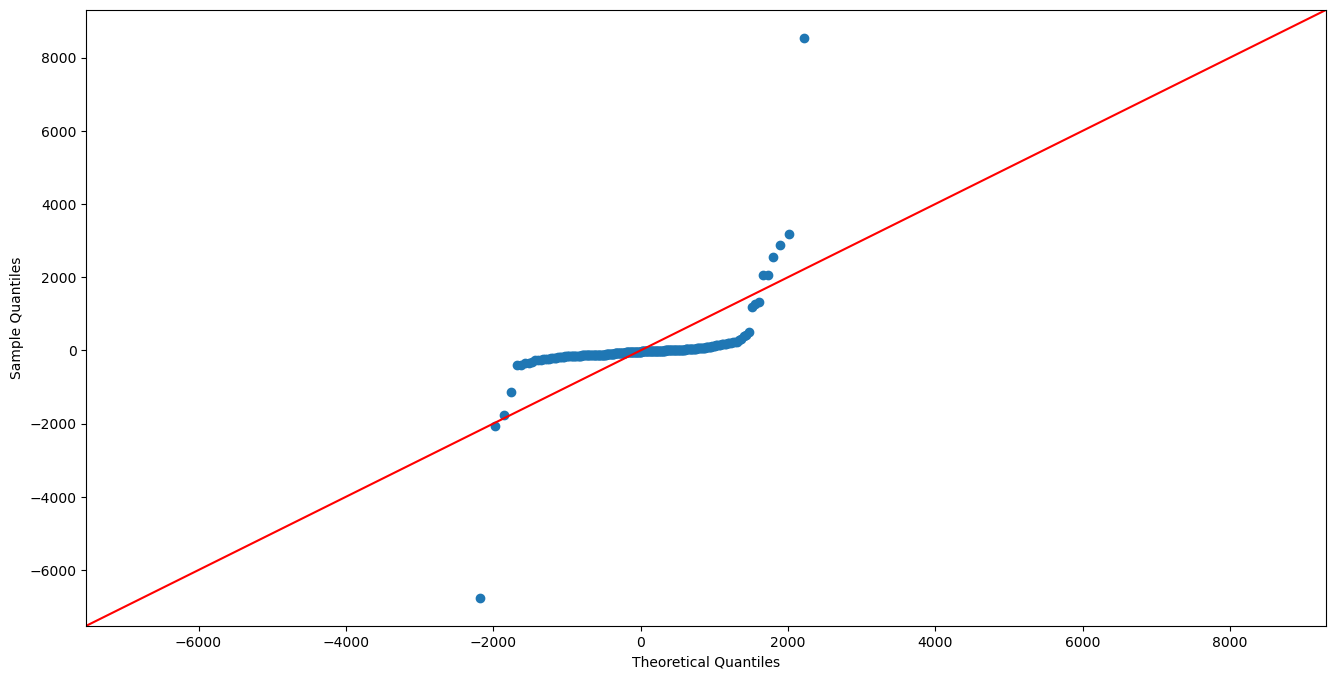

In [274]:
fig, ax = plt.subplots(figsize=(16,8))
sm.qqplot(resid['residuals'], loc=resid['residuals'].mean(), scale = resid['residuals'].std(), line='45', ax=ax)
fig.show()

# Предсказание будущих показателей

In [275]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              New cases   No. Observations:                  246
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -1995.594
Date:                Mon, 15 Dec 2025   AIC                           4001.189
Time:                        21:19:50   BIC                           4018.695
Sample:                    03-31-2020   HQIC                          4008.239
                         - 12-10-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6424      0.016    101.605      0.000       1.611       1.674
ar.L2         -1.0670      0.031    -34.281      0.000      -1.128      -1.006
ar.L3          0.2925      0.023     12.767      0.000       0.248       0.337
ma.L1         -1.0000      0.017    -59.679      0.000      -1.033      -0.967
sigma2      6.848e+05   2.45e-08    2.8e+13      0.000    6.85e+05    6.85e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             40286.61
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               4.04   Skew:                             2.74
Prob(H) (two-sided):                  0.00   Kurtosis:                        65.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.73e+27. Standard errors may be unstable.
"""

In [293]:
pred

2024-12-17     996.772498
2024-12-24     970.446382
2024-12-31     952.803089
2025-01-07     936.650582
2025-01-14     923.315790
2025-01-21     916.389113
2025-01-28     915.406021
2025-02-04     919.946197
2025-02-11    1022.704678
2025-02-18    1285.442523
Freq: W-TUE, Name: predicted_mean, dtype: float64

Последняя дата во временном ряду:  2024-12-10 00:00:00
Предсказание на 10 недель, до: 2025-02-18 00:00:00


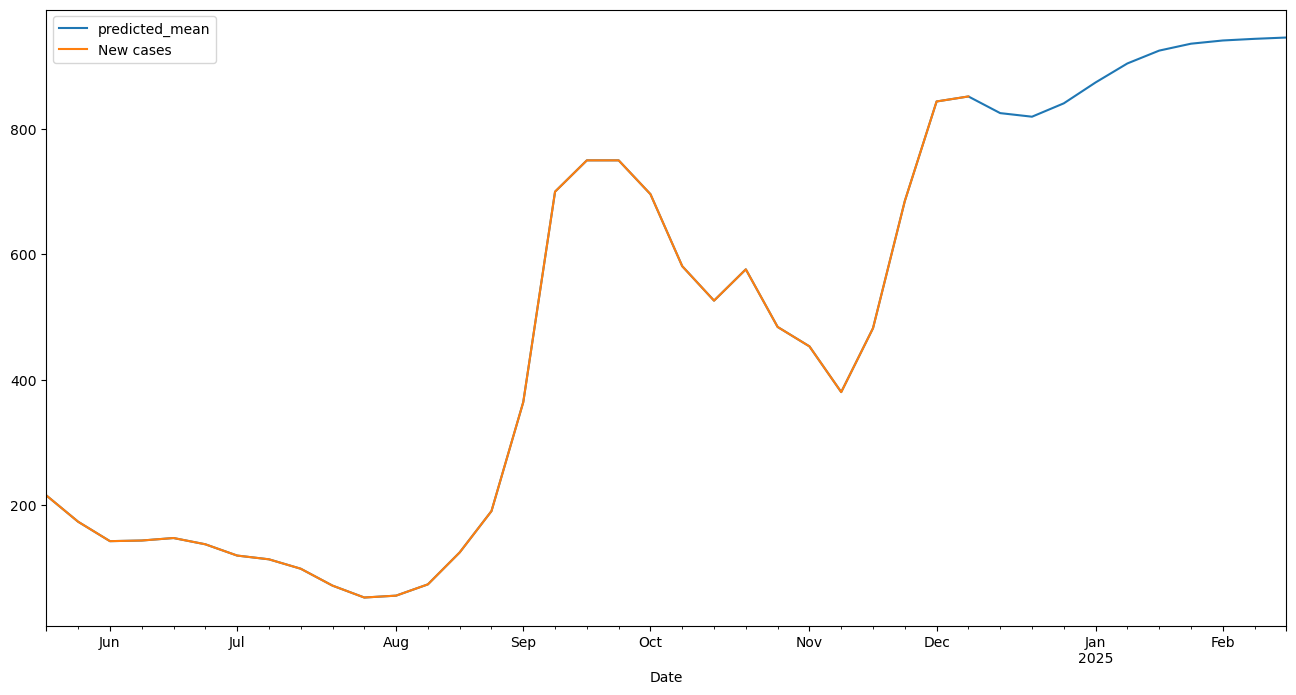

In [298]:
weeks_pred = 10 # количество недель для предсказания !!!!!!!!!!!!!

print("Последняя дата во временном ряду: ", ts.index[-1])
print(f"Предсказание на {weeks_pred} недель, до: {ts.index[-1] + timedelta(weeks=weeks_pred)}")

fig, ax = plt.subplots(figsize=(16,8))
pred = model.predict(start=ts.index[-1] + timedelta(weeks = 1), end=ts.index[-1] + timedelta(weeks=weeks_pred)).to_frame()
old_plus_pred = pd.concat([ts[-30:].rename({'New cases': 'predicted_mean'}, axis=1), pred], axis=0)

old_plus_pred.plot(ax=ax)
ts[-30:].plot(ax=ax)
plt.legend()

In [299]:
pred = model.predict(start=ts.index[-1] + timedelta(weeks=1), end=(ts.index[-1] + timedelta(weeks=weeks_pred)))
pred

2024-12-17    825.403128
2024-12-24    819.684120
2024-12-31    841.010508
2025-01-07    874.361454
2025-01-14    904.709348
2025-01-21    925.203948
2025-01-28    936.236273
2025-02-04    941.363052
2025-02-11    944.005323
2025-02-18    946.101087
Freq: W-TUE, Name: predicted_mean, dtype: float64

## Сохраняем предсказания и доверительные интервалы в Excel-файл

In [279]:
forecast = pd.DataFrame(columns=['value','left_border','right_border'], index=pred.index)
res = model.get_forecast(weeks_pred)
forecast['value'] = res.predicted_mean
forecast['left_border'] = res.conf_int()['lower New cases']
forecast['right_border'] = res.conf_int()['upper New cases']
forecast.to_excel('forecast.xlsx')
forecast

,value,left_border,right_border
2024-12-17,825.403128,-799.773938,2450.580195
2024-12-24,819.684120,-2310.852854,3950.221094
2024-12-31,841.010508,-3271.419655,4953.440671
2025-01-07,874.361454,-3701.511683,5450.234590
2025-01-14,904.709348,-3835.895996,5645.314691
2025-01-21,925.203948,-3863.833986,5714.241883
2025-01-28,936.236273,-3868.358039,5740.830585
2025-02-04,941.363052,-3871.243444,5753.969548
2025-02-11,944.005323,-3875.002776,5763.013422
2025-02-18,946.101087,-3878.399553,5770.601727


# Добавим сезонность и построим SARIMA

Общий вид модели - **SARIMA (p,d,q) (P,D,Q) s**

* p - порядок модели AR
* d - порядок интегрирования
* q - порядок модели MA
* P - порядок сезонной составляющей SAR
* D - порядок интегрирования сезонной составляющей
* Q - порядок сезонной составляющей SMA
* s - размерность сезонности

### Для начала надо провести сдвиг по сезонности, можно попробовать разные, рекомендуемый 4 месяца.

Сезонная разность:
Критерий Дики-Фуллера: p=0.000000
Ряд стационарен, d подходит
Критерий Дики-Фуллера с константой: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой и трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой, линейным и квадратичным трендом: p=0.000001
Ряд стационарен
Критерий Дики-Фуллера без константы и тренда: p=0.000000
Ряд стационарен
------------------------------
КPSS тест
Критические значения статистики:

10%: 0.119 5%: 0.146 2.5%: 0.176 1%: 0.216

Порядок лага   	Значение статистики    	P-value        
1              	0.09148915173691094    	0.1            
2              	0.06633400760016153    	0.1            
3              	0.05478535196290271    	0.1            
4              	0.04844203882274097    	0.1            
5              	0.04453304546005519    	0.1            
6              	0.041914761319981925   	0.1            
7              	0.04004046616257319    	0.1            
8              	0.03863173042168812    	0.1    

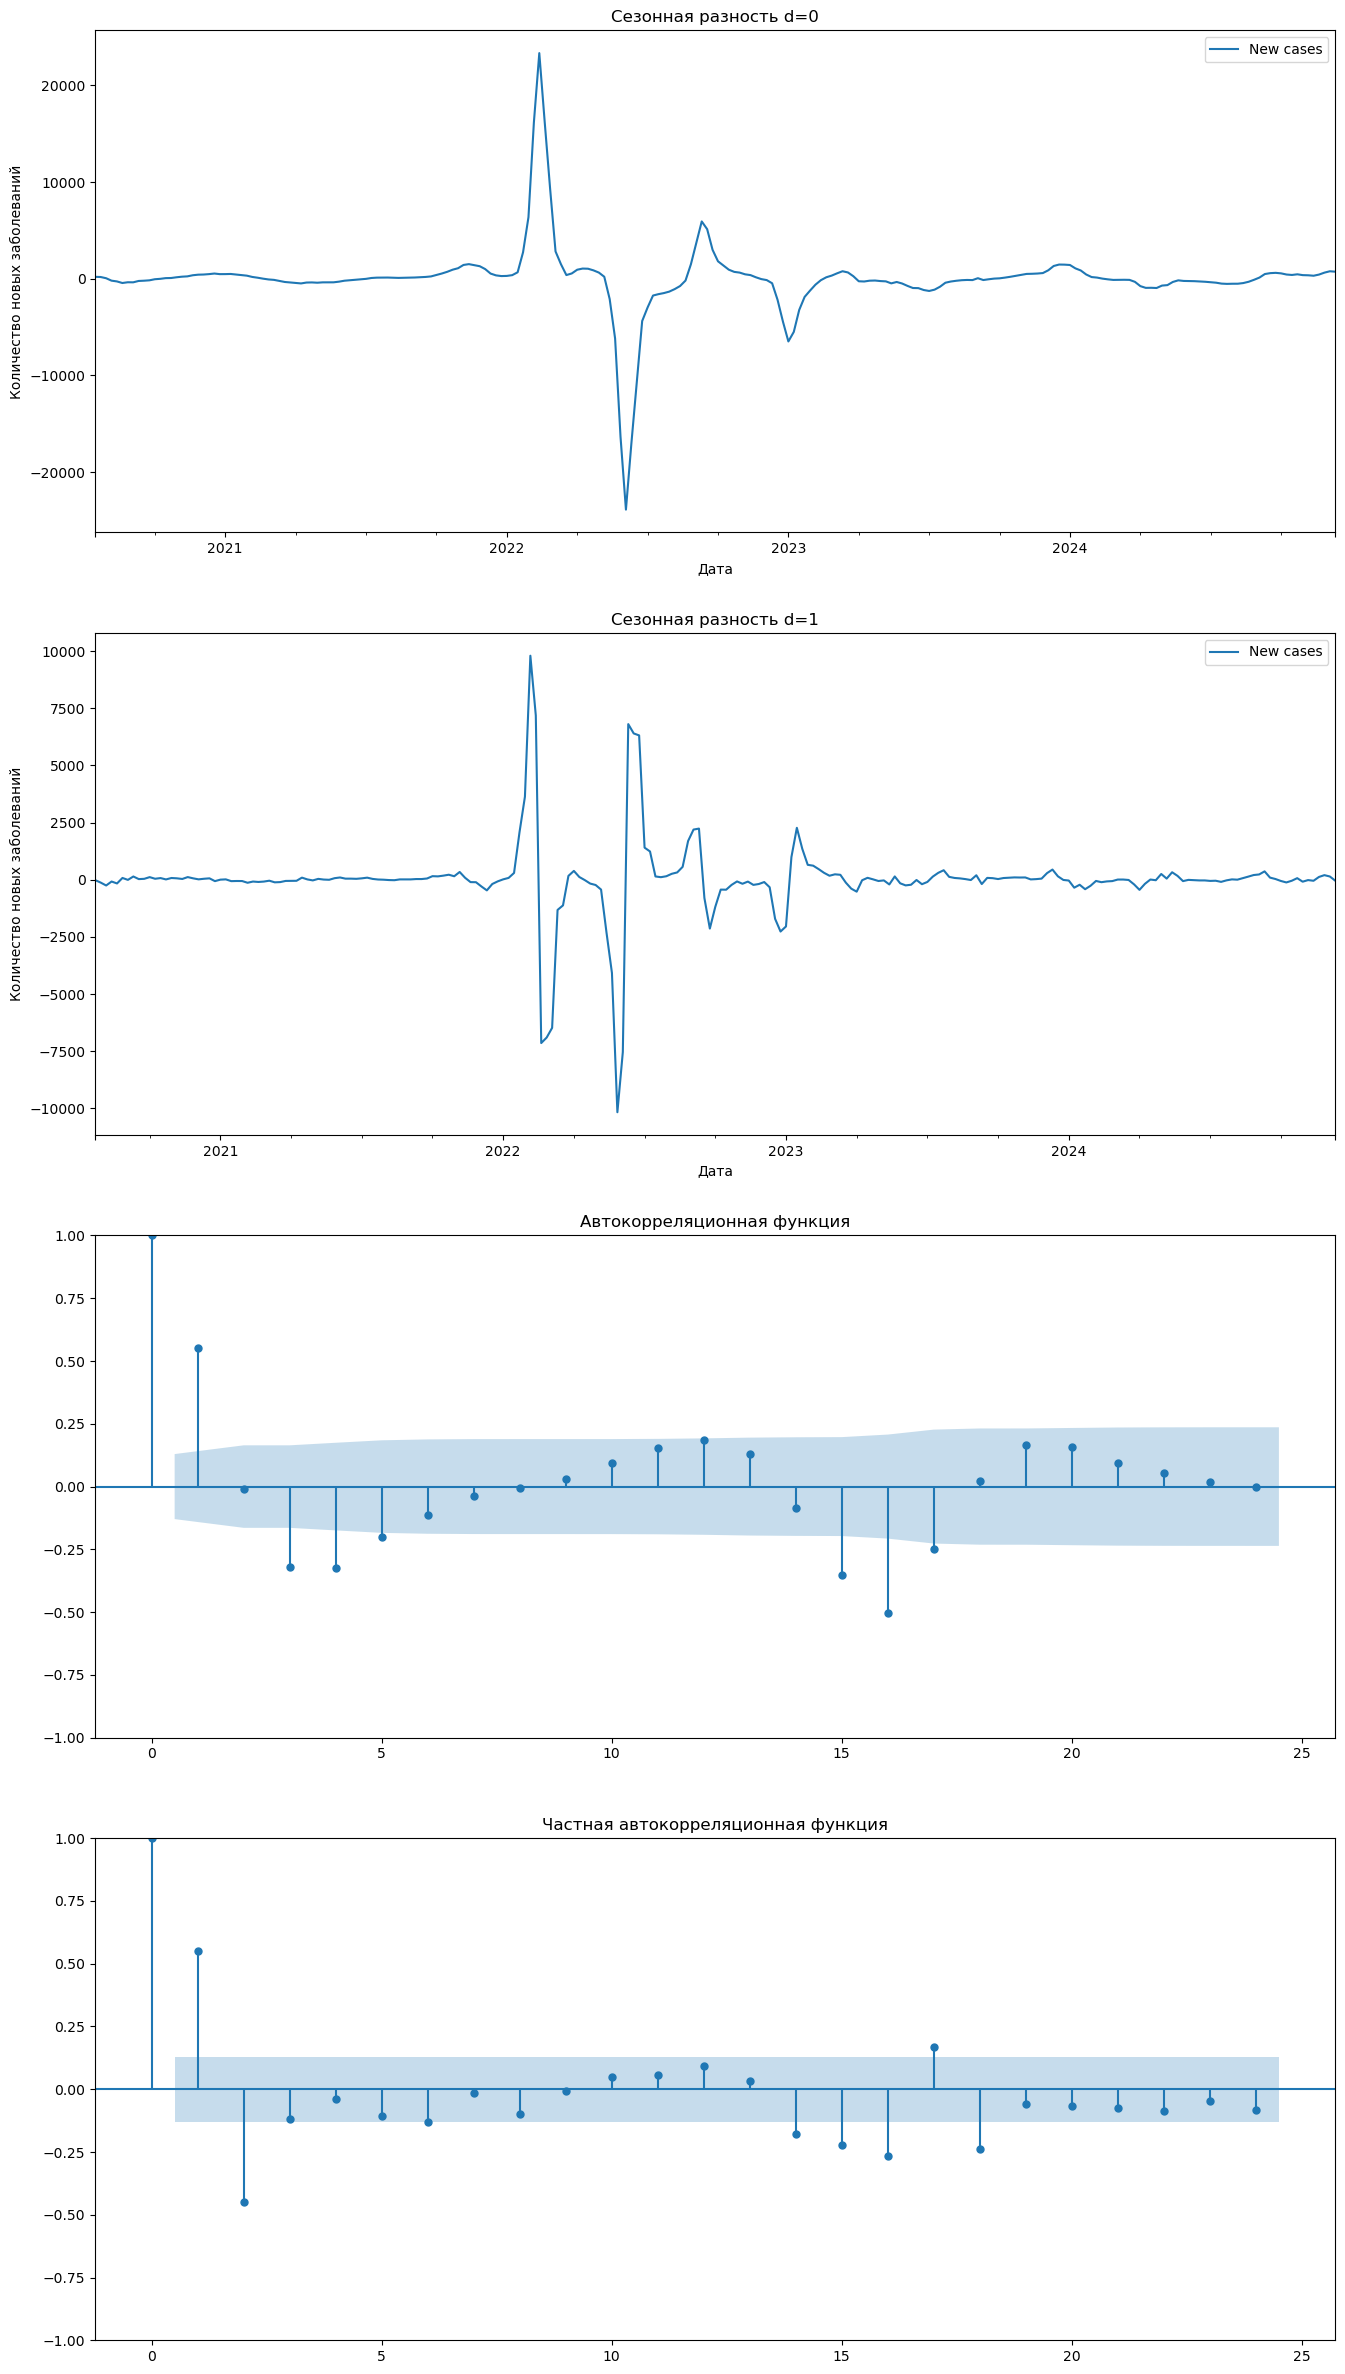

In [280]:
months_seasonal = 4 # !!!!!!!!!!!!


ts_4m = ts.diff(4*months_seasonal).dropna()
print("Сезонная разность:")
adf_test(ts_4m)
print('-'*30)
KPSS_test(ts_4m)

print("-"*30)
dif_4m = ts.diff(4*months_seasonal).diff().dropna()
print("Интегрированная сезонная разность:")
adf_test(dif_4m)
print('-'*30)
KPSS_test(dif_4m)

# dif2_4m = ts.diff(4*monhts_seasonal).diff().diff().dropna()
# adf_test(dif2_4m)

fig = plt.figure(figsize=(16,30))

ax0 = fig.add_subplot(411)
ts_4m.plot(ax=ax0)
ax0.set_title('Сезонная разность d=0')
ax0.set_xlabel('Дата')
ax0.set_ylabel('Количество новых заболеваний')

ax0 = fig.add_subplot(412)
dif_4m.plot(ax=ax0)
ax0.set_title('Сезонная разность d=1')
ax0.set_xlabel('Дата')
ax0.set_ylabel('Количество новых заболеваний')

ax1 = fig.add_subplot(413)
fig = sm.graphics.tsa.plot_acf(dif_4m, ax=ax1)
ax1.set_title('Автокорреляционная функция')

ax2 = fig.add_subplot(414)
fig = sm.graphics.tsa.plot_pacf(dif_4m, ax=ax2)
ax2.set_title('Частная автокорреляционная функция')

fig.show()

### P и Q определяются по графикам АКФ и ЧАКФ для подходящего значения D сезонной разности

In [281]:
%%time

#Модель SARIMA тренируется долго - если ставить значения параметров больше 1 время растет в геометрической прогресии...

p = 1
d = 1
q = 1
P = 1
D = 1
Q = 1
s = 4 * months_seasonal

sarima = sm.tsa.statespace.SARIMAX(ts, order=(p, d, q),
                                seasonal_order=(P, D, Q, s)).fit()
print(sarima.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10
 This problem is unconstrained.

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.88613D+00    |proj g|=  5.57712D-02

At iterate    5    f=  7.85014D+00    |proj g|=  2.24199D-03

At iterate   10    f=  7.85006D+00    |proj g|=  1.24114D-03

At iterate   15    f=  7.84858D+00    |proj g|=  1.26725D-02

At iterate   20    f=  7.76005D+00    |proj g|=  8.11835D-02

At iterate   25    f=  7.74736D+00    |proj g|=  3.53729D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5    

---

# Проверка адекватности сезонной модели

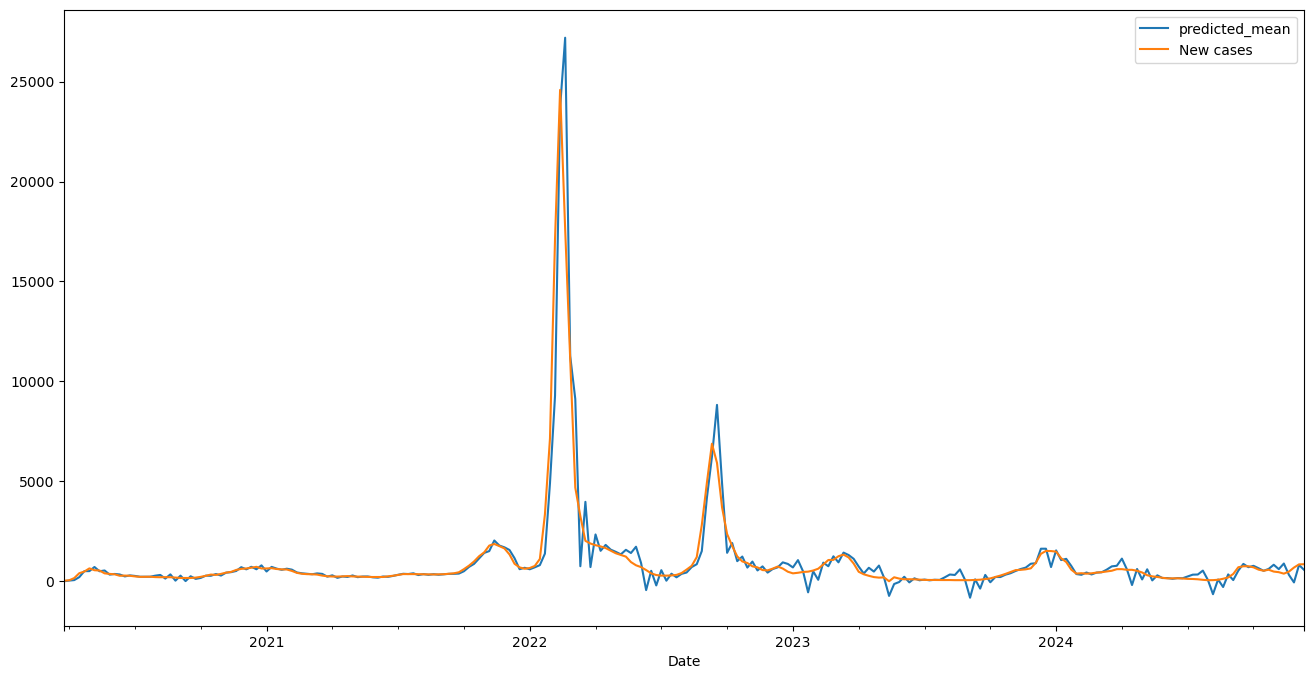

In [282]:
fig, ax = plt.subplots(figsize=(16,8))
pred = sarima.predict()
pred.plot(ax=ax)
ts.plot(ax=ax)
plt.legend()
fig.show()

In [283]:
print('MSE =', metrics.mean_squared_error(ts, pred))
print('RMSE =', np.sqrt(metrics.mean_squared_error(ts, pred)))
print('MAE =', metrics.mean_absolute_error(ts, pred))
print('MAPE =', metrics.mean_absolute_percentage_error(ts, pred))
print('R2 =', metrics.r2_score(ts, pred))

MSE = 900208.8356484182
RMSE = 948.7933577172736
MAE = 308.3473117733721
MAPE = 1.3441578349302862e+16
R2 = 0.8460253450563437


# Проверка нормальности остатков

Критерий Дики-Фуллера: p=0.000000
Ряд стационарен, d подходит
Критерий Дики-Фуллера с константой: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой и трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера с константой, линейным и квадратичным трендом: p=0.000000
Ряд стационарен
Критерий Дики-Фуллера без константы и тренда: p=0.000000
Ряд стационарен
------------------------------
КPSS тест
Критические значения статистики:

10%: 0.119 5%: 0.146 2.5%: 0.176 1%: 0.216

Порядок лага   	Значение статистики    	P-value        
1              	0.00850061300140414    	0.1            
2              	0.008513563211845312   	0.1            
3              	0.00979245643672566    	0.1            
4              	0.011609541230458804   	0.1            
5              	0.013469785898096626   	0.1            
6              	0.01571980947147895    	0.1            
7              	0.017789968595805422   	0.1            
8              	0.020122862157805118   	0.1            
9         

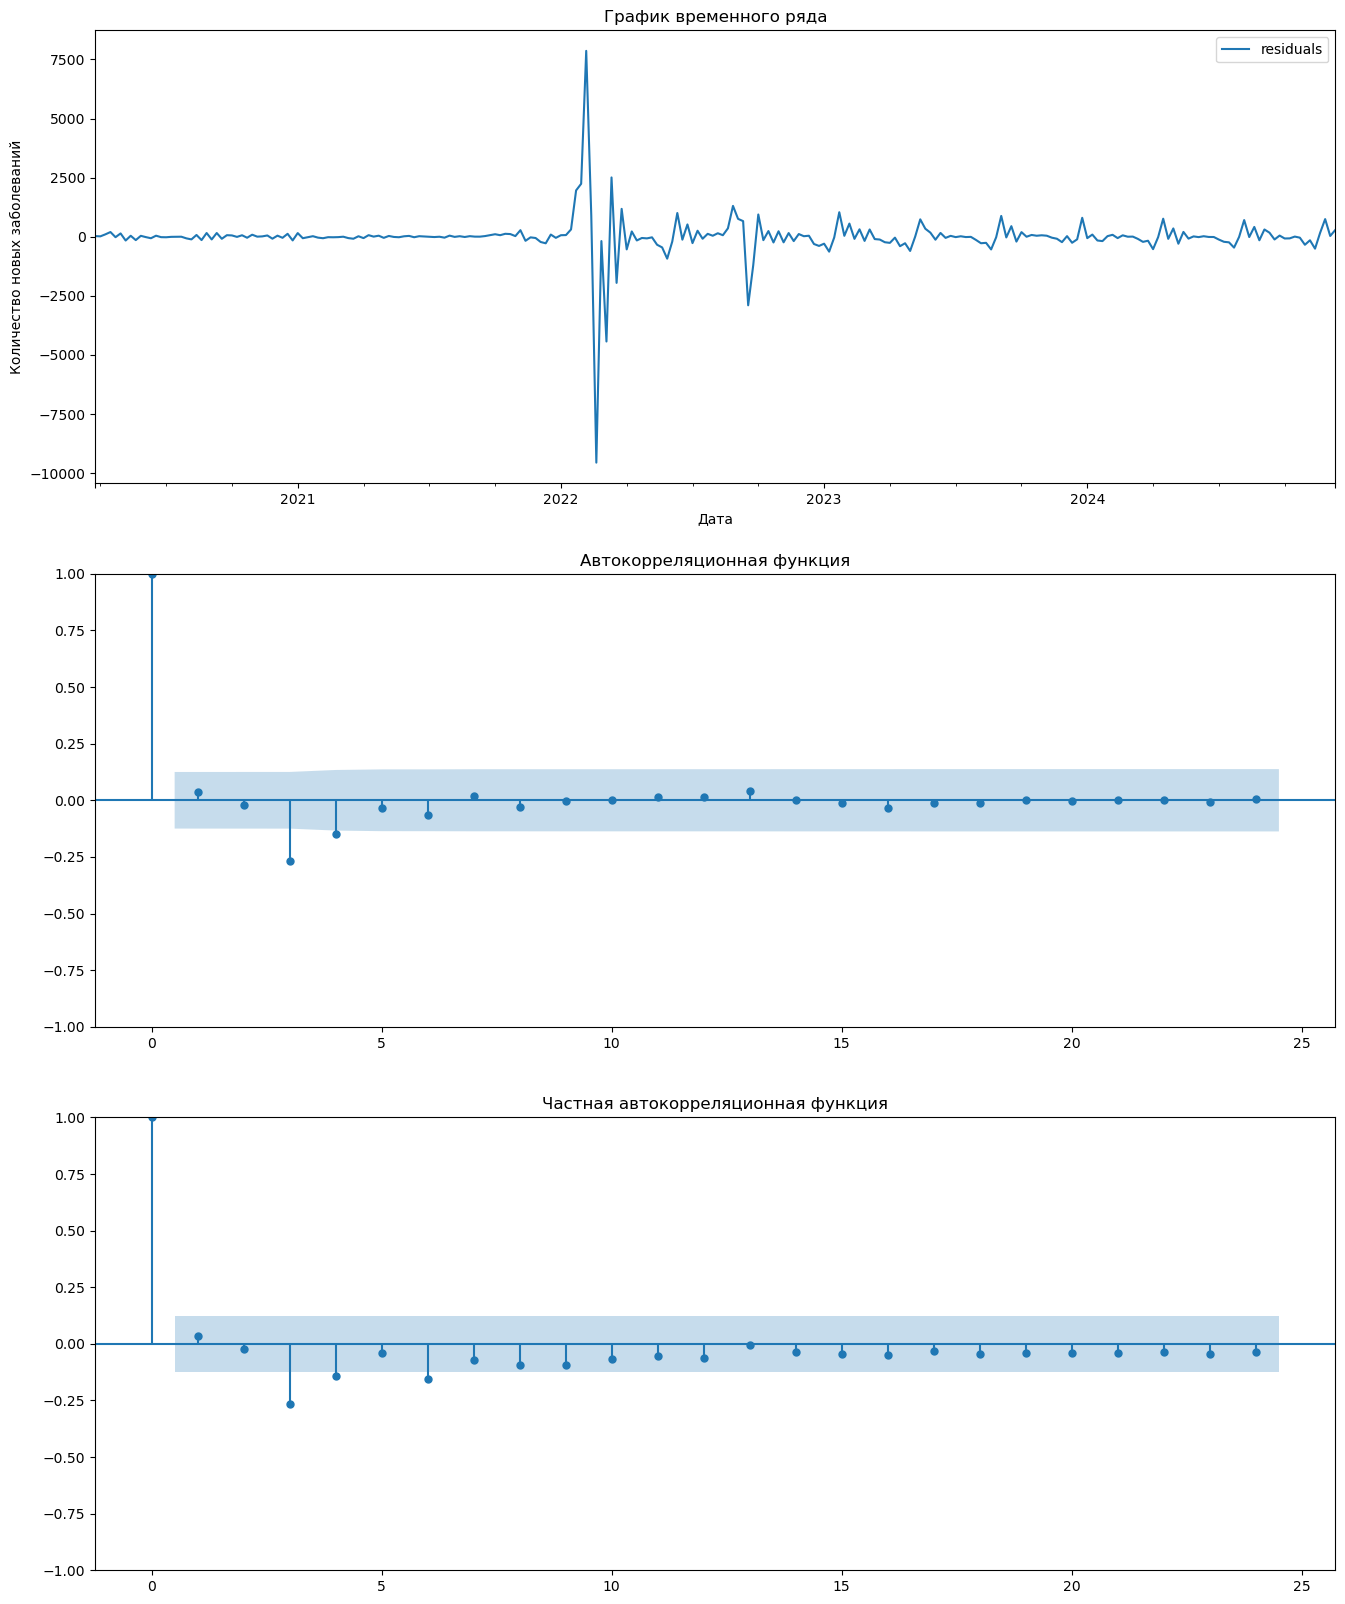

In [284]:
resid = pd.DataFrame(sarima.resid, columns=['residuals'])
adf_test(resid)
print('-'*30)
KPSS_test(resid)
plot_acf_pacf(resid)

Тест на нормальность: p = 0.000000
Распределение остатков ненормальное


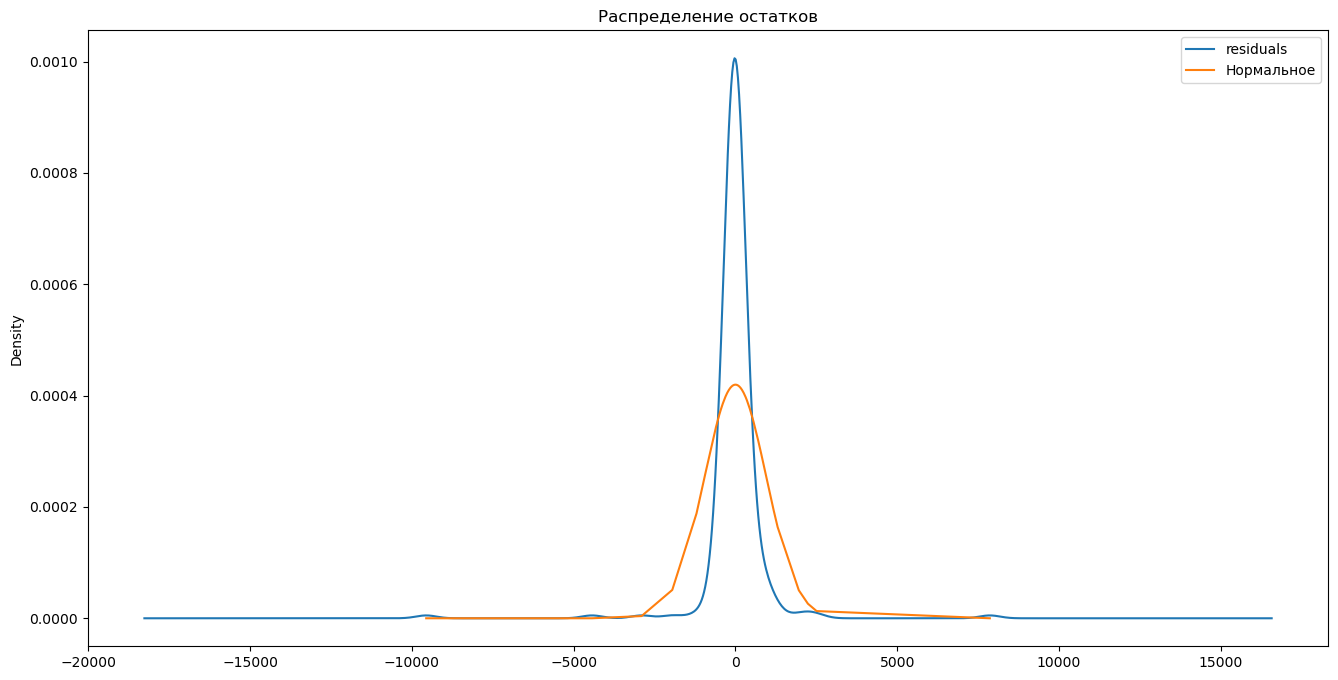

In [285]:
pvalue = sts.normaltest(resid['residuals'])[1]
print("Тест на нормальность: p = %f" % pvalue)
if pvalue > 0.05:
    print("Распределение остатков нормальное")
else:
    print("Распределение остатков ненормальное")

fig, ax = plt.subplots(figsize=(16,8))
resid.plot.kde(ax=ax)
plt.title('Распределение остатков')
plt.plot(resid.sort_values(by = 'residuals'), sts.norm.pdf(resid.sort_values(by = 'residuals'), resid.mean(), resid.std()), label='Нормальное')
plt.legend()
fig.show()

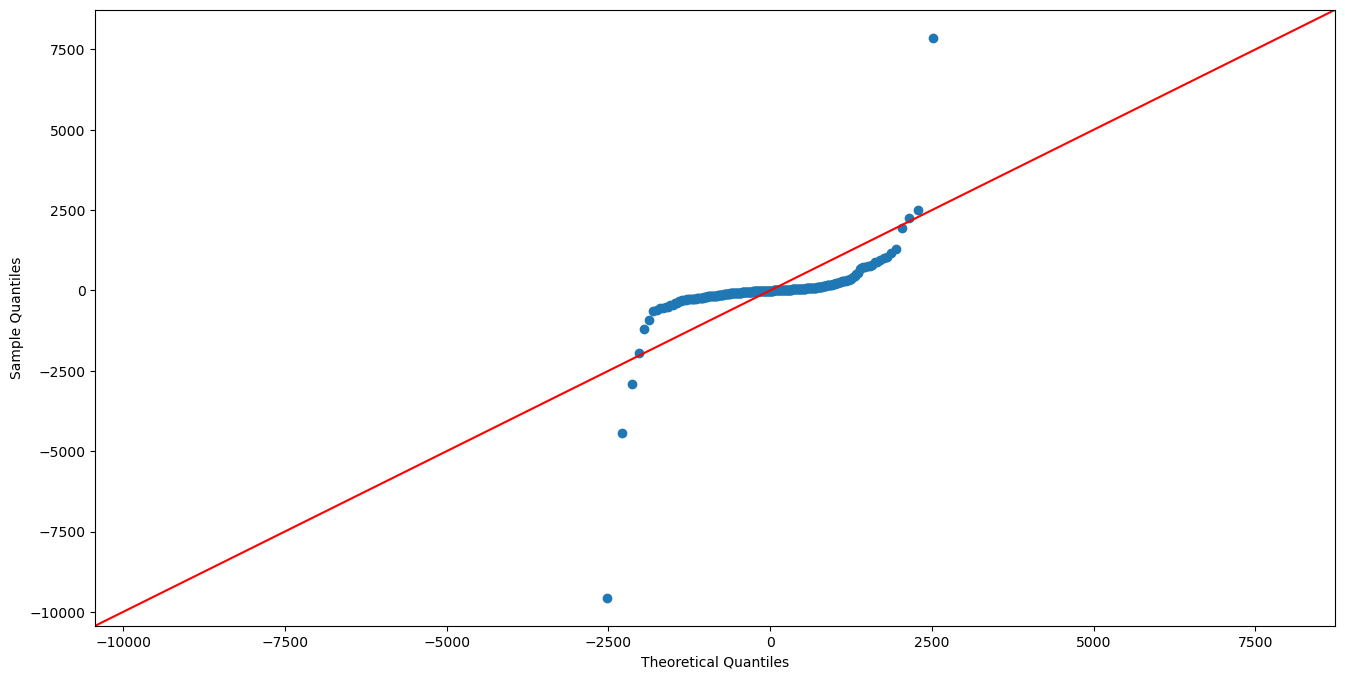

In [286]:
fig, ax = plt.subplots(figsize=(16,8))
sm.qqplot(resid['residuals'], loc=resid['residuals'].mean(), scale = resid['residuals'].std(), line='45', ax=ax)
fig.show()

# Предсказание будущих показателей

In [287]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          New cases   No. Observations:                  246
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 16)   Log Likelihood               -1905.852
Date:                            Mon, 15 Dec 2025   AIC                           3821.703
Time:                                    21:19:56   BIC                           3838.872
Sample:                                03-31-2020   HQIC                          3828.629
                                     - 12-10-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2913      0.023     12.608      0.000       0.246       0.337
ma.L1          0.4623      0.032     14.425      0.000       0.399       0.525
ar.S.L16      -0.0169      0.075     -0.226      0.822      -0.163       0.130
ma.S.L16      -0.9980      0.022    -45.470      0.000      -1.041      -0.955
sigma2      8.473e+05   2.61e-08   3.24e+13      0.000    8.47e+05    8.47e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.27   Jarque-Bera (JB):             30208.17
Prob(Q):                              0.60   Prob(JB):                         0.00
Heteroskedasticity (H):              12.88   Skew:                            -2.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        59.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.96e+28. Standard errors may be unstable.
"""

Последняя дата во временном ряду:  2024-12-10 00:00:00
Предсказание на 10 недель, до: 2025-02-18 00:00:00


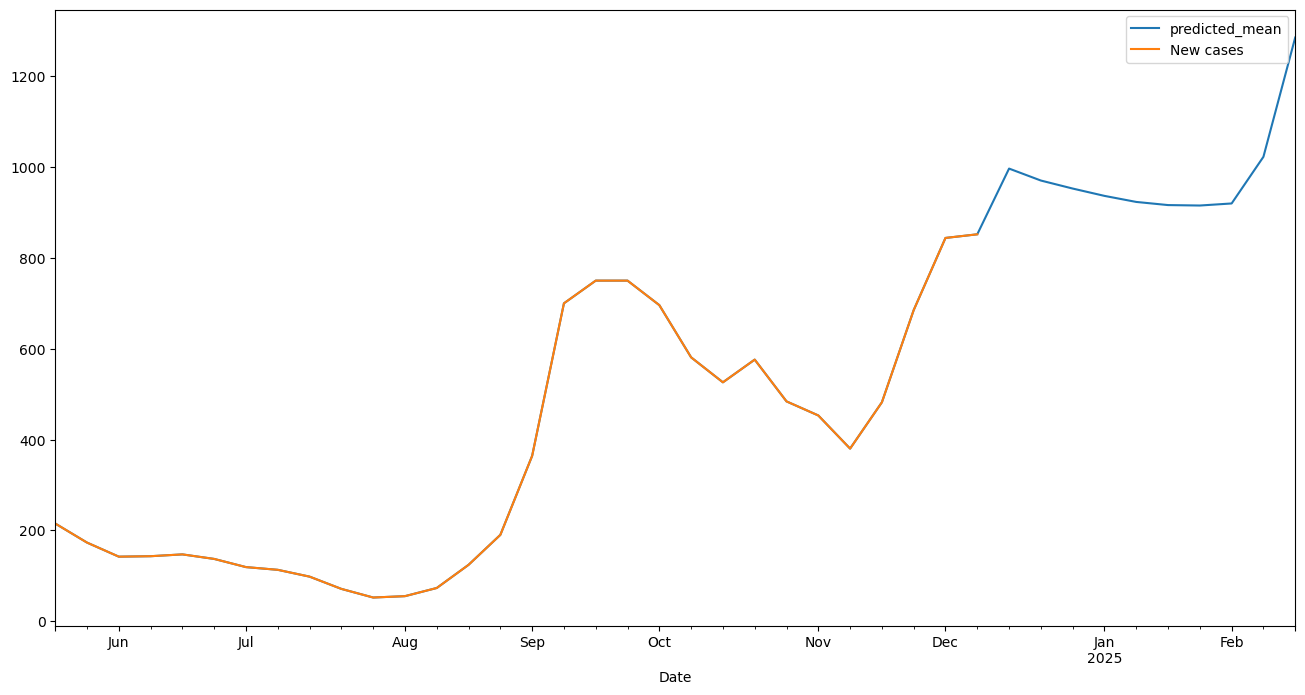

In [300]:
weeks_pred = 10 # количество недель для предсказания !!!!!!!!!!!!!

print("Последняя дата во временном ряду: ", ts.index[-1])
print(f"Предсказание на {weeks_pred} недель, до: {ts.index[-1] + timedelta(weeks=weeks_pred)}")

fig, ax = plt.subplots(figsize=(16,8))
pred = sarima.predict(start=ts.index[-1] + timedelta(weeks = 1), end=(ts.index[-1] + timedelta(weeks=weeks_pred))).to_frame()
old_plus_pred = pd.concat([ts[-30:].rename({'New cases': 'predicted_mean'}, axis = 1), pred], axis=0)

old_plus_pred.plot(ax=ax)
ts[-30:].plot(ax=ax)
plt.legend()
fig.show()

In [289]:
pred = sarima.predict(start=ts.index[-1] + timedelta(weeks=1), end=(ts.index[-1] + timedelta(weeks=weeks_pred)))
pred

2024-12-17     996.772498
2024-12-24     970.446382
2024-12-31     952.803089
2025-01-07     936.650582
2025-01-14     923.315790
2025-01-21     916.389113
2025-01-28     915.406021
2025-02-04     919.946197
2025-02-11    1022.704678
2025-02-18    1285.442523
Freq: W-TUE, Name: predicted_mean, dtype: float64

## Сохраняем предсказания  в Excel-файл

In [290]:
forecast = pd.DataFrame(columns=['value','left_border','right_border'], index=pred.index)
res = sarima.get_forecast(weeks_pred)
forecast['value'] = res.predicted_mean
forecast['left_border'] = res.conf_int()['lower New cases']
forecast['right_border'] = res.conf_int()['upper New cases']
forecast.to_excel('forecast_sarima.xlsx')
forecast

,value,left_border,right_border
2024-12-17,996.772498,-863.066711,2856.611708
2024-12-24,970.446382,-2782.884900,4723.777665
2024-12-31,952.803089,-4294.893629,6200.499807
2025-01-07,936.650582,-5534.352873,7407.654037
2025-01-14,923.315790,-6591.499431,8438.131010
2025-01-21,916.389113,-7518.542224,9351.320450
2025-01-28,915.406021,-8349.914544,10180.726586
2025-02-04,919.946197,-9107.554472,10947.446866
2025-02-11,1022.704678,-9713.064599,11758.473955
2025-02-18,1285.442523,-10114.414738,12685.299785
